# Correlation Inflation in CCA

**Author:** Luis Sierra Muntané  
**Date:** 27th May 2026

*Python adaptation of the original R Markdown notebook.*

## Setup

Consider two datasets $\mathbf{X}\in\mathbb{R}^{n\times p}$ and $\mathbf{Y}\in\mathbb{R}^{n\times q}$ where $n$ denotes the number of samples common to both datasets and $p,q$ denote that number of variables in each. In this way, we can understand the data matrices as $n$ i.i.d. realizations of the mean-zero random vectors $X\in \mathbb{R}^p$ and $Y\in \mathbb{R}^q$. The goal in Canonical Correlation Analysis (CCA) is that of finding directions $\mathbf{a}\in \mathbb{R}^p,\, \mathbf{b}\in\mathbb{R}^q$ such that the correlation of $\mathbf{a}^\top X$ and $\mathbf{b}^\top Y$ is maximized.

Let $\Sigma_X = \mathrm{Var}(X)$, $\Sigma_Y = {\rm Var}(Y)$ and $\Sigma_{XY} = \mathrm{Cov}(X,Y) = \mathbb{E}[XY^\top]$. We wish to maximize the expression

\begin{equation}
\rho(\mathbf{a},\mathbf{b}) = \frac{\mathbf{a}^\top\Sigma_{XY}\mathbf{b}}{\sqrt{\mathbf{a}^\top \Sigma_X \mathbf{a}\mathbf{b}^\top \Sigma_Y \mathbf{b}}}.
\end{equation}

In practice we replace these (usually unknown) covariances with their sample counterparts. In this notebook, we present some effects that appear as a consequence of this replacement.

We use NumPy for the linear algebra and Matplotlib for plotting. R's base function `cancor()` is not available in Python, so we implement a small helper that mirrors its behavior: centering the columns, taking QR decompositions of $X$ and $Y$, and returning the singular values of $Q_X^\top Q_Y$, i.e. the sample canonical correlations.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def cancor(X, Y):
    """Returns the canonical correlations and directions between the columns of X and Y.

    Aims to be a copy of the R function stats::cancor by centering each matrix, taking
    the QR decompositions, and returning the singular values of Q_X^T @ Q_Y.
    """
    X = X - X.mean(axis=0) # center each feature column so its sample mean is zero
    Y = Y - Y.mean(axis=0)
    Qx, _ = np.linalg.qr(X)  # QR removes redundant scaling information and gives normalized bases for the two column spaces.
    Qy, _ = np.linalg.qr(Y)
    return np.linalg.svd(Qx.T @ Qy, compute_uv=False)

# The diagonal values in D (UDV(T)) are the singular values. 
# In this QR-based formulation, those singular values are exactly the sample canonical correlations.

## Base example of large-dimensional asymptotics

Showing the largest canonical correlation of independent Gaussian data as $p/n$ grows while keeping $q/n$ fixed, that is, one of the data matrix's variables increases with respect to the number of samples. Note that the population canonical correlations are all equal to zero since the data distribution is composed of two independent isotropic Gaussians (the joint population covariance $\Sigma_{XY}$ is block diagonal, and in particular, the identity).

As the result of this numerical experiment, we can observe how the canonical correlations increase far beyond the value of their population counterparts, even for relatively modest ratios of $p/n$. We refer to this as _canonical correlation inflation_.

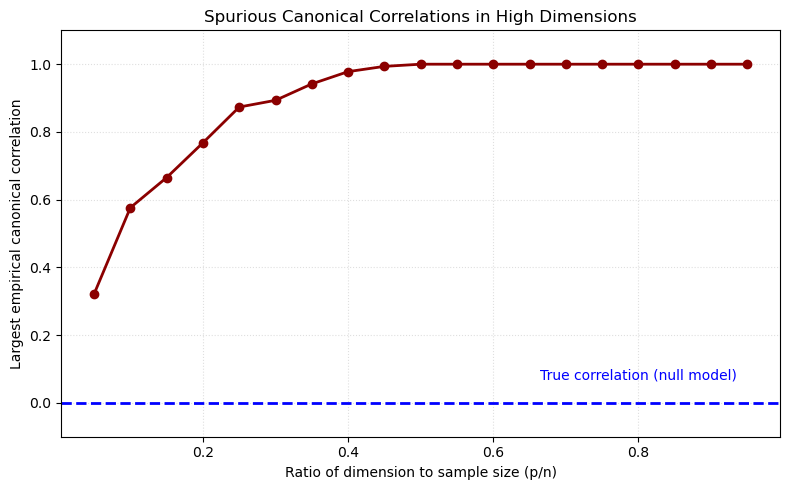

In [3]:
# Simulation parameters
rng = np.random.default_rng(123)
n = 200                                     # Fixed sample size
p_ratios = np.arange(0.05, 0.951, 0.05)     # p/n from 5% to 95%
max_corrs = np.zeros(len(p_ratios))         # Leading canonical correlation

# Simulation
# We strictly keep p, q < n because standard CCA requires inverting covariance matrices.
# If p >= n, the empirical correlation becomes 1
for i, ratio in enumerate(p_ratios):
    p = int(np.floor(n * ratio))

    # Generate null data (standard Gaussian noise)
    X = rng.standard_normal((n, p))
    Y = rng.standard_normal((n, p))

    # Store the largest canonical correlation (the first one)
    max_corrs[i] = cancor(X, Y)[0]

# Plots
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(p_ratios, max_corrs, '-o', color='darkred', lw=2, markersize=6,
        label='Largest empirical canonical correlation')
ax.axhline(0, color='blue', linestyle='--', lw=2)
ax.text(0.8, 0.07, 'True correlation (null model)', color='blue', ha='center')
ax.set_ylim(-0.1, 1.1)
ax.set_title('Spurious Canonical Correlations in High Dimensions')
ax.set_xlabel('Ratio of dimension to sample size (p/n)')
ax.set_ylabel('Largest empirical canonical correlation')
ax.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()


### Largest 10 canonical correlations

In this section we plot the ten largest sample canonical correlations and observe how they both all grow substantially, and the difference between them lessens. That is, as $p/n \rightarrow 1$, the canonical correlations $\rho_i \rightarrow 1$.

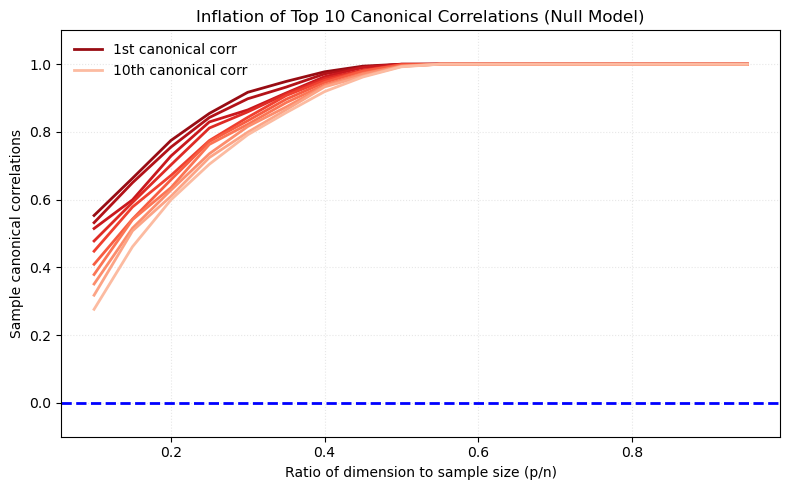

In [4]:
# Simulation parameters
rng = np.random.default_rng(123)
n = 200
k_track = 10                                  # Top correlations to track
p_ratios = np.arange(0.10, 0.951, 0.05)
results = np.zeros((len(p_ratios), k_track))

# Simulation
for i, ratio in enumerate(p_ratios):
    p = int(np.floor(n * ratio))

    X = rng.standard_normal((n, p))
    Y = rng.standard_normal((n, p))

    corrs = cancor(X, Y)
    num_to_take = min(p, k_track)
    results[i, :num_to_take] = corrs[:num_to_take]

# Plots show gradient of reds from dark (top corr) to light (10th corr)
reds = plt.get_cmap('Reds')(np.linspace(0.9, 0.25, k_track))

fig, ax = plt.subplots(figsize=(8, 5))
for j in range(k_track):
    ax.plot(p_ratios, results[:, j], color=reds[j], lw=2)

ax.axhline(0, color='blue', linestyle='--', lw=2)
ax.set_ylim(-0.1, 1.1)
ax.set_title('Inflation of Top 10 Canonical Correlations (Null Model)')
ax.set_xlabel('Ratio of dimension to sample size (p/n)')
ax.set_ylabel('Sample canonical correlations')

# Legend showing only the extremes (1st and 10th)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=reds[0], lw=2, label='1st canonical corr'),
    Line2D([0], [0], color=reds[-1], lw=2, label='10th canonical corr'),
]
ax.legend(handles=legend_elements, loc='upper left', frameon=False)
ax.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()
plt.savefig('top10_corrs.png')
plt.show()


### Theoretical value of top canonical correlation from the Wachter Law

Under the null model with $X, Y$ independent Gaussians and $p/n \to \gamma$, the support of the limiting spectrum of squared canonical correlations is bounded above by $2\sqrt{\gamma(1-\gamma)}$ for $\gamma < 1/2$, and the top correlation saturates at $1$ for $\gamma \ge 1/2$. This is sometimes referred to as the Wachter Law, and we can check that the largest sample canonical correlation indeed closely follows the path dictated by this law.

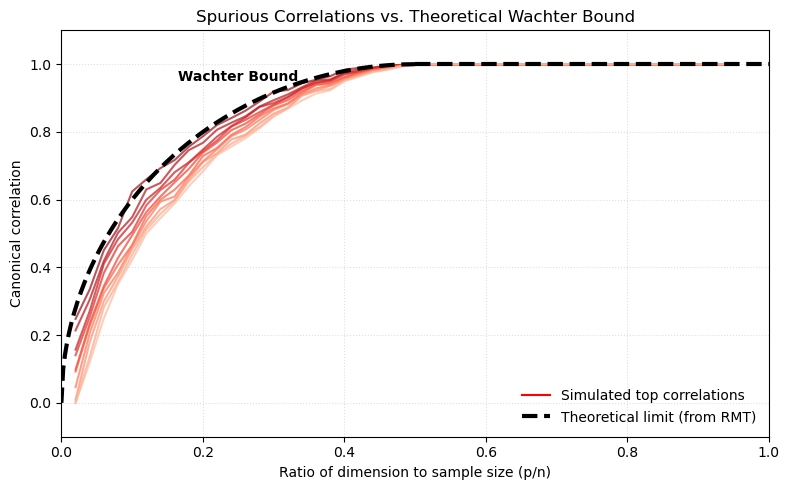

In [5]:
# Simulation parameters
rng = np.random.default_rng(123)
n = 400
k_track = 10
p_ratios = np.arange(0.02, 0.951, 0.02)
results = np.zeros((len(p_ratios), k_track))

# Simulation
for i, ratio in enumerate(p_ratios):
    p = int(np.floor(n * ratio))

    X = rng.standard_normal((n, p))
    Y = rng.standard_normal((n, p))

    corrs = cancor(X, Y)
    num_to_take = min(p, k_track)
    results[i, :num_to_take] = corrs[:num_to_take]

# Plots
reds = plt.get_cmap('Reds')(np.linspace(0.9, 0.25, k_track))

fig, ax = plt.subplots(figsize=(8, 5))
for j in range(k_track):
    ax.plot(p_ratios, results[:, j], color=reds[j], lw=1.5, alpha=0.7)

# Overlay of theoretical asymptotic limit using the Wachter Law from RMT
# 2*sqrt(gamma * (1 - gamma)) is valid only for gamma < 0.5;
# at gamma >= 0.5 the top canonical correlation saturates at 1.
x_bound = np.linspace(0.0, 0.5, 200)
ax.plot(x_bound, 2 * np.sqrt(x_bound * (1 - x_bound)),
        color='black', lw=3, linestyle='--')
ax.plot([0.5, 1.0], [1.0, 1.0], color='black', lw=3, linestyle='--')

ax.set_xlim(0, 1)
ax.set_ylim(-0.1, 1.1)
ax.set_title('Spurious Correlations vs. Theoretical Wachter Bound')
ax.set_xlabel('Ratio of dimension to sample size (p/n)')
ax.set_ylabel('Canonical correlation')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='red', lw=1.5, label='Simulated top correlations'),
    Line2D([0], [0], color='black', lw=3, linestyle='--', label='Theoretical limit (from RMT)'),
]
ax.legend(handles=legend_elements, loc='lower right', frameon=False)
ax.grid(True, linestyle=':', alpha=0.4)
ax.text(0.25, 0.95, 'Wachter Bound', color='black', fontweight='bold', ha='center')
plt.tight_layout()
plt.show()


### Both variable counts are high-dimensional

For completion, we also include a short analysis of the case where both variable dimensions $p,q$ grow with respect to the sample size. We can define proportionaliy parameters $\gamma_p = p/n$ and $\gamma_q = q/n$. In the following we check the behaviour of the largest and smallest canonical correlations in this _high-dimensional_ setting and compare them with their corresponding theoretical laws from Random Matrix Theory. To do so, we employ four distinct plots, two heatmaps for 2D data representations and two line graphs showing the evolution of the canonical correlations as the ratio between $\gamma_p$ and $\gamma_q$ changes.

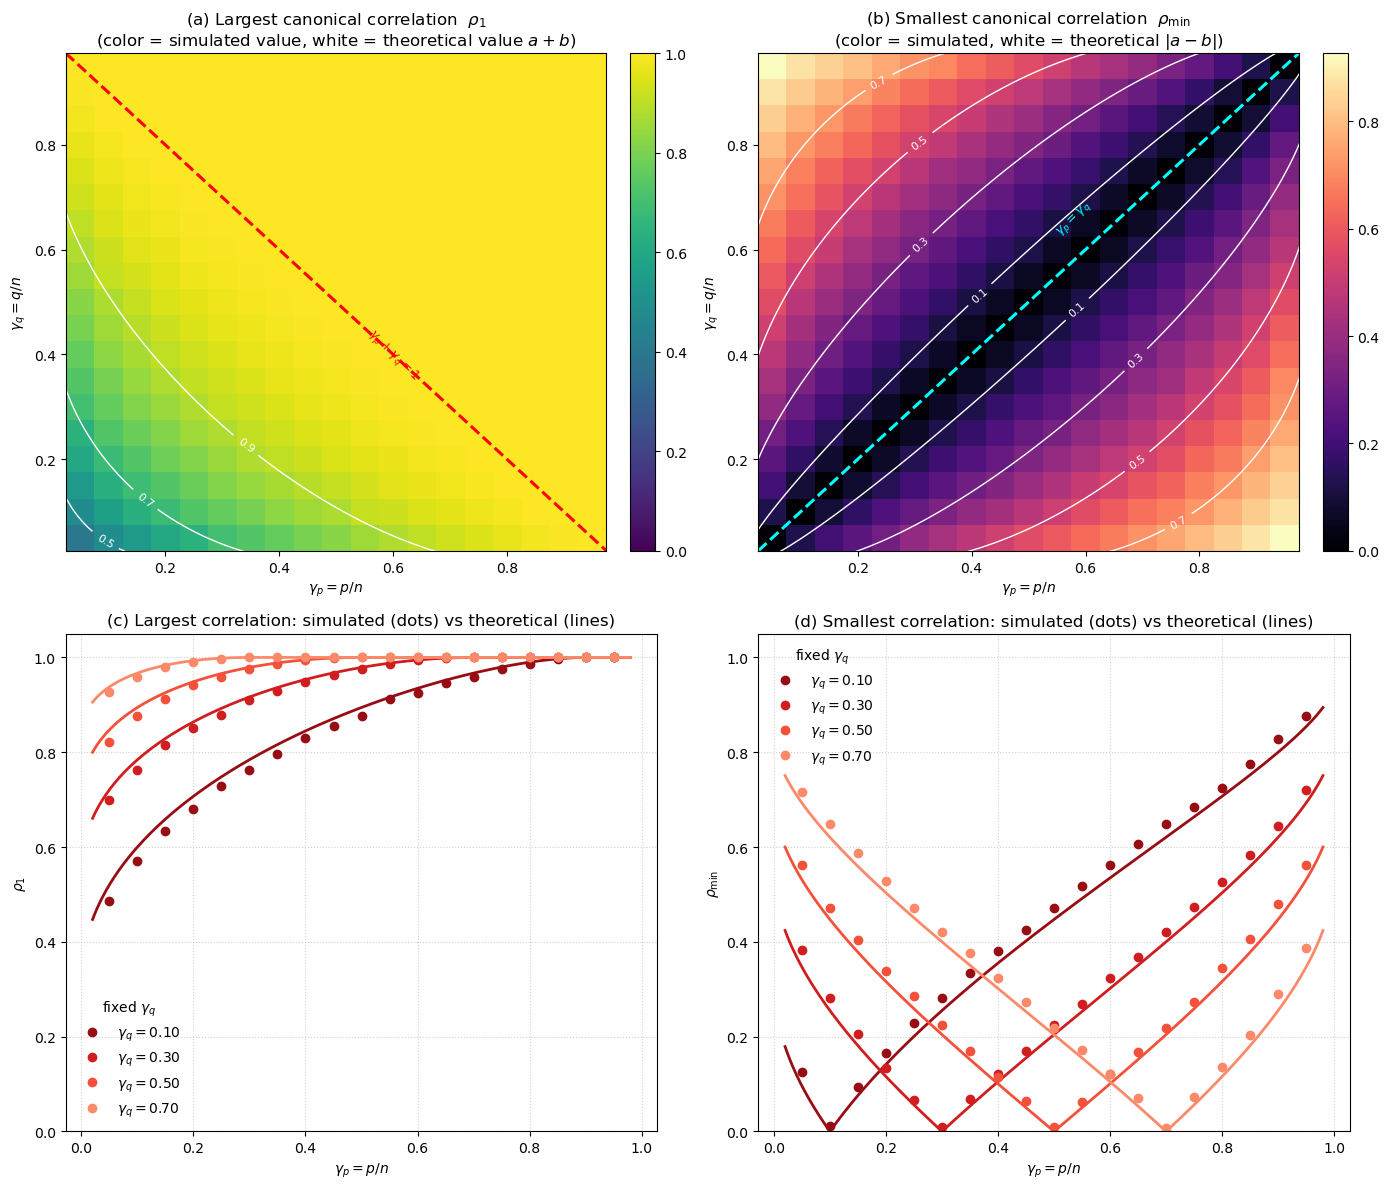

In [8]:
def wachter_edges(gp, gq):
    """Function that computes the theoretical edges of the canonical-correlation spectrum.

    Returns (upper, lower). The upper edge saturates at 1 above the
    degeneracy line gamma_p + gamma_q = 1 because of the atom at 1.
    """
    a = np.sqrt(gp * (1.0 - gq))
    b = np.sqrt(gq * (1.0 - gp))
    upper = np.where(gp + gq >= 1.0, 1.0, a + b)
    lower = np.abs(a - b)
    return upper, lower


# Simulation over the (gamma_p, gamma_q) grid
rng = np.random.default_rng(123)
n = 200
n_rep = 25                                       # Monte Carlo replications per cell
gammas = np.round(np.arange(0.05, 0.96, 0.05), 2)
G = len(gammas)

rho_top = np.full((G, G), np.nan)                # largest canonical correlation
rho_bot = np.full((G, G), np.nan)                # smallest canonical correlation

# CCA is symmetric under swapping X and Y, so the spectrum at (gp, gq) equals
# the one at (gq, gp). Thus, calculating the upper triangle is sufficient.
for iq, gq in enumerate(gammas):
    for ip, gp in enumerate(gammas):
        if gp > gq:
            continue
        p = int(np.floor(n * gp))
        q = int(np.floor(n * gq))
        tops = np.empty(n_rep)
        bots = np.empty(n_rep)
        for r in range(n_rep):
            X = rng.standard_normal((n, p))
            Y = rng.standard_normal((n, q))
            corrs = cancor(X, Y)
            tops[r] = corrs[0]
            bots[r] = corrs[-1]
        rho_top[iq, ip] = rho_top[ip, iq] = tops.mean()
        rho_bot[iq, ip] = rho_bot[ip, iq] = bots.mean()

# Theoretical surfaces on the grid for smooth contours
fine = np.linspace(0.02, 0.98, 240)
GP, GQ = np.meshgrid(fine, fine)
TOP_th, BOT_th = wachter_edges(GP, GQ)

half = (gammas[1] - gammas[0])/2
extent = [gammas[0] - half, gammas[-1] + half,
          gammas[0] - half, gammas[-1] + half]

# Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# (a) Plot of first canonical correlation: heatmap with RMT theoretical contours
ax = axes[0, 0]
im = ax.imshow(rho_top, origin='lower', extent=extent, aspect='auto',
               cmap='viridis', vmin=0, vmax=1)
cs = ax.contour(GP, GQ, TOP_th, levels=[0.3, 0.5, 0.7, 0.9],
                colors='white', linewidths=1.0)
ax.clabel(cs, inline=True, fontsize=8, fmt='%.1f')
ax.plot([extent[0], 1 - extent[0]], [1 - extent[0], extent[0]],
        'r--', lw=2.2)
ax.text(0.60, 0.40, r'$\gamma_p+\gamma_q=1$', color='red', fontsize=9,
        rotation=-45, ha='center', va='center')
ax.set(xlim=extent[:2], ylim=extent[2:],
       xlabel=r'$\gamma_p = p/n$', ylabel=r'$\gamma_q = q/n$',
       title='(a) Largest canonical correlation  $\\rho_1$\n'
             '(color = simulated value, white = theoretical value $a+b$)')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# (b) Plot of smallest canonical correlation: heatmap with RMT theoretical contours
ax = axes[0, 1]
im = ax.imshow(rho_bot, origin='lower', extent=extent, aspect='auto',
               cmap='magma', vmin=0, vmax=float(np.nanmax(rho_bot)))
cs = ax.contour(GP, GQ, BOT_th, levels=[0.1, 0.3, 0.5, 0.7],
                colors='white', linewidths=1.0)
ax.clabel(cs, inline=True, fontsize=8, fmt='%.1f')
ax.plot([extent[0], extent[1]], [extent[0], extent[1]],
        '--', color='cyan', lw=2.2)
ax.text(0.58, 0.66, r'$\gamma_p=\gamma_q$', color='cyan', fontsize=9,
        rotation=45, ha='center', va='center')
ax.set(xlim=extent[:2], ylim=extent[2:],
       xlabel=r'$\gamma_p = p/n$', ylabel=r'$\gamma_q = q/n$',
       title='(b) Smallest canonical correlation  $\\rho_{\\min}$\n'
             '(color = simulated, white = theoretical $|a-b|$)')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Fixed-gamma_q slices for the two lower panels
slice_qs = [0.10, 0.30, 0.50, 0.70]
slice_cols = plt.get_cmap('Reds')(np.linspace(0.9, 0.4, len(slice_qs)))

# (c) Largest correlation: simulated (dots) vs theory (lines)
ax = axes[1, 0]
for gq, col in zip(slice_qs, slice_cols):
    iq = int(np.argmin(np.abs(gammas - gq)))
    ax.plot(gammas, rho_top[iq, :], 'o', color=col, ms=6,
            label=f'$\\gamma_q = {gammas[iq]:.2f}$')
    top_th, _ = wachter_edges(fine, gammas[iq])
    ax.plot(fine, top_th, '-', color=col, lw=2)
ax.set(ylim=(0, 1.05), xlabel=r'$\gamma_p = p/n$', ylabel=r'$\rho_1$',
       title='(c) Largest correlation: simulated (dots) vs theoretical (lines)')
ax.legend(frameon=False, title=r'fixed $\gamma_q$')
ax.grid(True, linestyle=':', alpha=0.6)

# (d) Smallest correlation: simulated (dots) vs theory (lines)
ax = axes[1, 1]
for gq, col in zip(slice_qs, slice_cols):
    iq = int(np.argmin(np.abs(gammas - gq)))
    ax.plot(gammas, rho_bot[iq, :], 'o', color=col, ms=6,
            label=f'$\\gamma_q = {gammas[iq]:.2f}$')
    _, bot_th = wachter_edges(fine, gammas[iq])
    ax.plot(fine, bot_th, '-', color=col, lw=2)
ax.set(ylim=(0, 1.05), xlabel=r'$\gamma_p = p/n$', ylabel=r'$\rho_{\min}$',
       title='(d) Smallest correlation: simulated (dots) vs theoretical (lines)')
ax.legend(frameon=False, title=r'fixed $\gamma_q$')
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## Regularization to avoid overinflation

In order to avoid the overfitting behaviour producing spurious canonical correlations despite a null model, we may replace the sample covariances $\hat\Sigma_{XX}$ and $\hat\Sigma_{YY}$ by their "ridge"-regularized versions $\hat\Sigma_{XX} + \lambda I$ and $\hat\Sigma_{YY} + \lambda I$. The canonical correlations are then the singular values of

$$T_\lambda = (\hat\Sigma_{XX} + \lambda I)^{-1/2}\, \hat\Sigma_{XY}\, (\hat\Sigma_{YY} + \lambda I)^{-1/2}.$$

Because $\lambda > 0$ keeps the matrices positive definite, this is well-defined even when $p \ge n$. Also note that the same regularization is applied to the covariance of both datasets, this being the standard approach, but it is also possible to use different values for the two covariance matrices. The sensibility of the latter approach of having different regularization parameters is made clear when, for instance, $p > n$ but $q < n$.

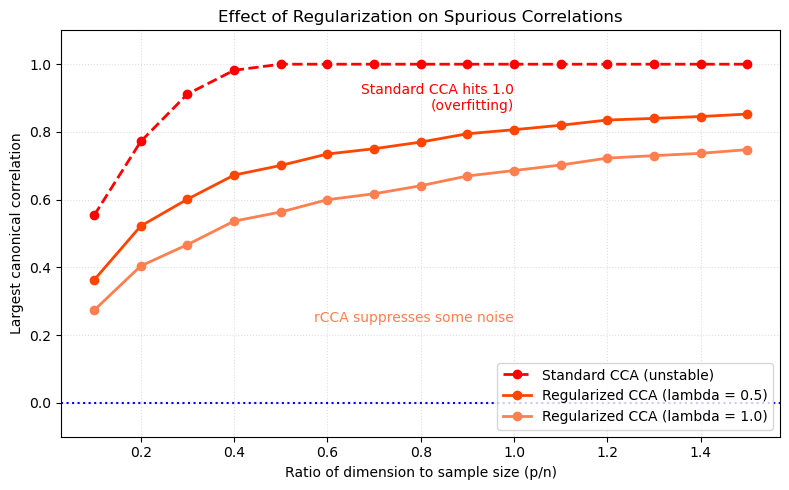

In [7]:
# Function for regularized CCA correlations
def rcca_correlations(X, Y, lam):
    """Return regularized canonical correlations (ridge penalty `lam`)."""
    n = X.shape[0]
    X = X - X.mean(axis=0)
    Y = Y - Y.mean(axis=0)

    # Empirical covariances (dividing by n for the MLE, we assume zero-mean)
    S_xx = (X.T @ X)/n
    S_yy = (Y.T @ Y)/n
    S_xy = (X.T @ Y)/n

    # Regularized empirical covariances
    S_xx_reg = S_xx + lam * np.eye(X.shape[1])
    S_yy_reg = S_yy + lam * np.eye(Y.shape[1])

    # Inverse square roots via symmetric eigendecomposition
    vals_x, vecs_x = np.linalg.eigh(S_xx_reg)
    S_xx_inv_sqrt = (vecs_x / np.sqrt(vals_x)) @ vecs_x.T

    vals_y, vecs_y = np.linalg.eigh(S_yy_reg)
    S_yy_inv_sqrt = (vecs_y / np.sqrt(vals_y)) @ vecs_y.T

    # T = S_xx^(-1/2) @ S_xy @ S_yy^(-1/2) with singular values
    # as the regularized canonical correlations.
    T_matrix = S_xx_inv_sqrt @ S_xy @ S_yy_inv_sqrt
    return np.linalg.svd(T_matrix, compute_uv=False)


# Simulation parameters
rng = np.random.default_rng(123)
n = 200
p_ratios = np.arange(0.1, 1.501, 0.1)
results_unreg = np.full(len(p_ratios), np.nan)
results_reg_1 = np.full(len(p_ratios), np.nan)
results_reg_2 = np.full(len(p_ratios), np.nan)

# Strength of regularization
lam_1 = 0.5
lam_2 = 1.0

# Simulation
for i, ratio in enumerate(p_ratios):
    p = int(np.floor(n * ratio))

    X = rng.standard_normal((n, p))
    Y = rng.standard_normal((n, p))

    # Standard CCA only when p < n (otherwise we trivially get corr=1)
    if p < n:
        results_unreg[i] = cancor(X, Y)[0]
    else:
        results_unreg[i] = 1.0

    results_reg_1[i] = rcca_correlations(X, Y, lam_1)[0]
    results_reg_2[i] = rcca_correlations(X, Y, lam_2)[0]

# Plots
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(p_ratios, results_unreg, '--o', color='red', lw=2, markersize=6,
        label='Standard CCA (unstable)')
ax.plot(p_ratios, results_reg_1, '-o', color='orangered', lw=2, markersize=6,
        label=f'Regularized CCA (lambda = {lam_1})')
ax.plot(p_ratios, results_reg_2, '-o', color='coral', lw=2, markersize=6,
        label=f'Regularized CCA (lambda = {lam_2})')

ax.axhline(0, color='blue', linestyle=':')
ax.set_ylim(-0.1, 1.1)
ax.set_title('Effect of Regularization on Spurious Correlations')
ax.set_xlabel('Ratio of dimension to sample size (p/n)')
ax.set_ylabel('Largest canonical correlation')
ax.legend(loc='lower right')
ax.grid(True, linestyle=':', alpha=0.4)

ax.text(1.0, 0.9, 'Standard CCA hits 1.0\n(overfitting)', color='red',
        ha='right', va='center')
ax.text(1.0, 0.25, 'rCCA suppresses some noise', color='coral',
        ha='right', va='center')
plt.tight_layout()
plt.savefig('regularized_cca.png')
plt.show()
